# Salary Prediction using Polynomial Regression

**Objective:** Build a Polynomial Regression model to predict employee salary based on position level, since the relationship between level and salary is non-linear.

**Dataset:** [Position Salaries Dataset (Kaggle)](https://www.kaggle.com/datasets/akram24/position-salaries)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

## Task 1: Data Understanding

In [2]:
# Load the dataset
df = pd.read_csv("salary.csv")

# Display first five records
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
# Dataset information and summary statistics
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [4]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
# Identify the input feature and target variable
input_feature = 'Level'   # Position is a text label duplicating Level, so Level is used as the numeric input
target_variable = 'Salary'

print("Input feature:", input_feature)
print("Target variable:", target_variable)

Input feature: Level
Target variable: Salary


## Task 2: Data Preprocessing

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64


In [7]:
# Select the appropriate feature(s) and target variable
# 'Position' is dropped since 'Level' already encodes the same information numerically
X = df[['Level']]
y = df['Salary']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nNote: this dataset only has 10 rows in total, so the 80/20 split")
print("produces a very small test set (2 rows). Results should be read with that in mind.")

Training set size: (8, 1)
Testing set size: (2, 1)

Note: this dataset only has 10 rows in total, so the 80/20 split
produces a very small test set (2 rows). Results should be read with that in mind.


## Task 3: Model Development

In [8]:
# Transform the input feature using Polynomial Features (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a Polynomial Regression model (Linear Regression on the polynomial-transformed features)
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

print("Predicted salaries:", y_pred)
print("Actual salaries:", y_test.values)

Predicted salaries: [606335.60051158  84934.8912917 ]
Actual salaries: [500000  50000]


## Task 4: Model Evaluation

In [9]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R\u00b2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R² Score: 0.8763


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


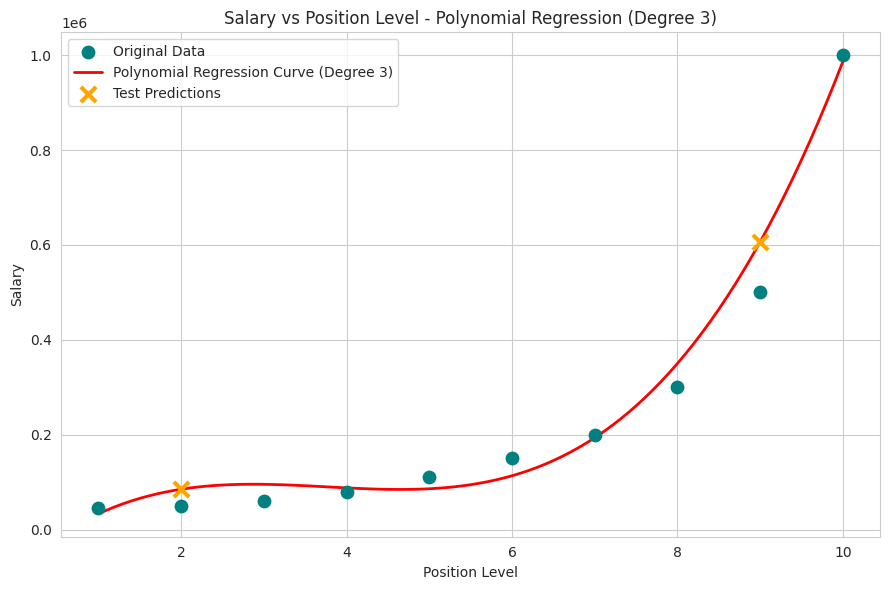

In [10]:
# Scatter plot of the original data + Polynomial Regression Curve
X_grid = np.arange(X['Level'].min(), X['Level'].max() + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='teal', s=80, label='Original Data', zorder=3)
plt.plot(X_grid, y_grid_pred, color='red', linewidth=2, label='Polynomial Regression Curve (Degree 3)')
plt.scatter(X_test, y_pred, color='orange', marker='x', s=120, linewidths=3, label='Test Predictions', zorder=4)
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Salary vs Position Level - Polynomial Regression (Degree 3)")
plt.legend()
plt.tight_layout()
plt.savefig("polynomial_regression_curve.png", dpi=150)
plt.show()

### Observations

1. **The degree-3 polynomial curve tracks the sharp upward curve in salary at higher position levels much better than a straight line could** — salary barely grows between levels 1-4, then rises steeply toward the CEO level, which is exactly the kind of non-linear pattern polynomial regression is built to capture.
2. **With only 10 data points total, the 80/20 split leaves just 2 rows for testing**, so the MAE/MSE/R² numbers here are more illustrative than statistically reliable — a small shift in which points land in the test set could change the metrics substantially.
3. **The model fits the training range well but would extrapolate poorly beyond it** — polynomial curves can swing sharply outside the range of the training data, so predictions for position levels beyond 10 shouldn't be trusted.

## Task 5: Conclusion

This project used Polynomial Regression (degree 3) to predict employee salary from position level, since the relationship between the two is clearly non-linear — salary stays relatively flat across junior levels and then rises sharply at senior levels. The polynomial curve captured this pattern well within the range of the training data, closely following the steep salary jump at the higher position levels that a straight line would have completely missed.

The key difference between Linear and Polynomial Regression is the shape of the relationship each can model: Linear Regression fits a single straight line and assumes a constant rate of change between the input and target, while Polynomial Regression fits a curve by adding higher-degree terms of the input feature, allowing the rate of change to vary across the range of values. This makes Polynomial Regression far better suited to a dataset like this one, where salary growth accelerates non-linearly with seniority rather than increasing by a fixed amount at each level. The main advantage of Polynomial Regression here is that it lets a fundamentally curved relationship be modeled using ordinary linear regression machinery, simply by transforming the input feature — with the caveat that, given how small this dataset is, the model should not be trusted to extrapolate confidently beyond the observed position levels.